In [1]:
!pip install torch torchvision fiftyone albumentations opencv-python-headless tqdm pycocotools torchmetrics

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of wsproto to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/17.8 MB 22.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 25.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 21.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 23.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 20.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━

In [1]:
!wget -q -nc https://github.com/ayooshkathuria/pytorch-yolo-v3/raw/master/dog-cycle-car.png

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda:0
GPU: NVIDIA GeForce RTX 2080 Ti


In [2]:
#Download COCO dataset

import fiftyone as fo
import fiftyone.zoo as foz

# List available zoo datasets
print(foz.list_zoo_datasets())

# Download the COCO-2017 validation split and load it into FiftyOne
dataset = foz.load_zoo_dataset("coco-2017", split="validation")
dataset.persistent = True

['activitynet-100', 'activitynet-200', 'bdd100k', 'caltech101', 'caltech256', 'cifar10', 'cifar100', 'cityscapes', 'coco-2014', 'coco-2017', 'fashion-mnist', 'fiw', 'hmdb51', 'imagenet-2012', 'imagenet-sample', 'kinetics-400', 'kinetics-600', 'kinetics-700', 'kinetics-700-2020', 'kitti', 'kitti-multiview', 'lfw', 'mnist', 'open-images-v6', 'open-images-v7', 'places', 'quickstart', 'quickstart-3d', 'quickstart-geo', 'quickstart-groups', 'quickstart-video', 'sama-coco', 'ucf101', 'voc-2007', 'voc-2012']
Found annotations at '/home/jupyter-st125990/fiftyone/coco-2017/raw/instances_val2017.json'
Images already downloaded
Existing download of split 'validation' is sufficient
Loading existing dataset 'coco-2017-validation'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [3]:
#Download darknet.py and util.py

import os
if not os.path.exists('darknet.py'):
    os.system('wget -q https://raw.githubusercontent.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch/master/darknet.py')
if not os.path.exists('util.py'):
    os.system('wget -q https://raw.githubusercontent.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch/master/util.py')

In [4]:
#Download YOLOv3.cfg

import os
os.makedirs('cfg', exist_ok=True)
if not os.path.exists('cfg/yolov3.cfg'):
    os.system('wget -q https://raw.githubusercontent.com/ayooshkathuria/YOLO_v3_tutorial_from_scratch/master/cfg/yolov3.cfg -O cfg/yolov3.cfg')

In [5]:
#Set Dataset paths

import os

fo_base   = os.path.expanduser('~/fiftyone/coco-2017')
path2data = os.path.join(fo_base, 'validation', 'data')
path2json = os.path.join(fo_base, 'raw', 'instances_val2017.json')

assert os.path.isdir(path2data),  f'Images not found: {path2data}'
assert os.path.isfile(path2json), f'Annotations not found: {path2json}'

print(f'Images     : {path2data}')
print(f'Annotations: {path2json}')

img_size = 416

Images     : /home/jupyter-st125990/fiftyone/coco-2017/validation/data
Annotations: /home/jupyter-st125990/fiftyone/coco-2017/raw/instances_val2017.json


In [6]:
# Define CustomCoco dataset class

# coding=utf-8
import os, sys, math, cv2, random, json
import numpy as np
import torch
from PIL import Image
from torchvision.datasets import CocoDetection
from typing import Any, Callable, Optional, Tuple

ANCHORS = [
    [[10, 13], [16, 30],  [33, 23]],
    [[30, 61], [62, 45],  [59, 119]],
    [[116, 90],[156, 198],[373, 326]],
]
STRIDES     = [8, 16, 32]
IP_SIZE     = img_size
NUM_ANCHORS = 3
NUM_CLASSES = 80

with open(path2json) as js:
    data = json.load(js)["categories"]

cats_dict = {}
for i, cat in enumerate(data[:80]):
    cats_dict[str(cat['id'])] = i


class CustomCoco(CocoDetection):
    def __init__(self, root, annFile, transform=None,
                 target_transform=None, transforms=None):
        super(CocoDetection, self).__init__(root, transforms, transform, target_transform)
        from pycocotools.coco import COCO
        self.coco = COCO(annFile)
        self.ids  = list(sorted(self.coco.imgs.keys()))

    def __getitem__(self, index):
        coco   = self.coco
        img_id = self.ids[index]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        target  = coco.loadAnns(ann_ids)
        path    = coco.loadImgs(img_id)[0]['file_name']

        img = Image.open(os.path.join(self.root, path)).convert('RGB')
        img = np.array(img)

        category_ids = [obj['category_id'] for obj in target]
        bboxes       = [obj['bbox']        for obj in target]

        if self.transform is not None:
            transformed  = self.transform(image=img, bboxes=bboxes, category_ids=category_ids)
            img          = transformed['image'],
            bboxes       = torch.Tensor(transformed['bboxes'])
            cat_ids      = torch.Tensor(transformed['category_ids'])
            labels, bboxes = self.__create_label(bboxes, cat_ids.type(torch.IntTensor))

        return img, labels, bboxes

    def __len__(self):
        return len(self.ids)

    def __create_label(self, bboxes, class_inds):
        bboxes      = np.array(bboxes)
        class_inds  = np.array(class_inds)
        strides     = np.array(STRIDES)
        train_output_size  = IP_SIZE / strides
        anchors_per_scale  = NUM_ANCHORS

        label = [
            np.zeros((int(train_output_size[i]), int(train_output_size[i]),
                       anchors_per_scale, 5 + NUM_CLASSES))
            for i in range(3)
        ]
        bboxes_xywh = [np.zeros((150, 4)) for _ in range(3)]
        bbox_count  = np.zeros((3,))

        for i in range(len(bboxes)):
            bbox_coor      = bboxes[i][:4]
            bbox_class_ind = cats_dict[str(class_inds[i])]

            one_hot = np.zeros(NUM_CLASSES, dtype=np.float32)
            one_hot[bbox_class_ind] = 1.0

            bbox_xywh = np.concatenate(
                [(0.5 * bbox_coor[2:] + bbox_coor[:2]), bbox_coor[2:]], axis=-1)
            bbox_xywh_scaled = 1.0 * bbox_xywh[np.newaxis, :] / strides[:, np.newaxis]

            iou = []
            exist_positive = False
            for i in range(3):
                anchors_xywh = np.zeros((anchors_per_scale, 4))
                anchors_xywh[:, 0:2] = np.floor(bbox_xywh_scaled[i, 0:2]).astype(np.int32) + 0.5
                anchors_xywh[:, 2:4] = ANCHORS[i]

                iou_scale = iou_xywh_numpy(bbox_xywh_scaled[i][np.newaxis, :], anchors_xywh)
                iou.append(iou_scale)
                iou_mask = iou_scale > 0.3

                if np.any(iou_mask):
                    xind, yind = np.floor(bbox_xywh_scaled[i, 0:2]).astype(np.int32)
                    label[i][yind, xind, iou_mask, 0:4] = bbox_xywh * strides[i]
                    label[i][yind, xind, iou_mask, 4:5] = 1.0
                    label[i][yind, xind, iou_mask, 5:]  = one_hot
                    bbox_ind = int(bbox_count[i] % 150)
                    bboxes_xywh[i][bbox_ind, :4] = bbox_xywh * strides[i]
                    bbox_count[i]  += 1
                    exist_positive  = True

            if not exist_positive:
                best_anchor_ind = np.argmax(np.array(iou).reshape(-1), axis=-1)
                best_detect = int(best_anchor_ind / anchors_per_scale)
                best_anchor = int(best_anchor_ind % anchors_per_scale)
                xind, yind  = np.floor(bbox_xywh_scaled[best_detect, 0:2]).astype(np.int32)
                label[best_detect][yind, xind, best_anchor, 0:4] = bbox_xywh * strides[best_detect]
                label[best_detect][yind, xind, best_anchor, 4:5] = 1.0
                label[best_detect][yind, xind, best_anchor, 5:]  = one_hot
                bbox_ind = int(bbox_count[best_detect] % 150)
                bboxes_xywh[best_detect][bbox_ind, :4] = bbox_xywh * strides[best_detect]
                bbox_count[best_detect] += 1

        fs = int(train_output_size[2]) * int(train_output_size[2]) * anchors_per_scale
        fm = int(train_output_size[1]) * int(train_output_size[1]) * anchors_per_scale
        fl = int(train_output_size[0]) * int(train_output_size[0]) * anchors_per_scale

        label_s = torch.Tensor(label[2]).view(1, fs, 5 + NUM_CLASSES).squeeze(0)
        label_m = torch.Tensor(label[1]).view(1, fm, 5 + NUM_CLASSES).squeeze(0)
        label_l = torch.Tensor(label[0]).view(1, fl, 5 + NUM_CLASSES).squeeze(0)

        bboxes_s = torch.Tensor(bboxes_xywh[2])
        bboxes_m = torch.Tensor(bboxes_xywh[1])
        bboxes_l = torch.Tensor(bboxes_xywh[0])

        labels = torch.cat([label_l, label_m, label_s], 0)
        bboxes = torch.cat([bboxes_l, bboxes_m, bboxes_s], 0)
        return labels, bboxes

In [7]:
#Define iou_xywh_numpy and CIOU_xywh_torch

def iou_xywh_numpy(boxes1, boxes2):
    boxes1 = np.array(boxes1)
    boxes2 = np.array(boxes2)

    boxes1_area = boxes1[..., 2] * boxes1[..., 3]
    boxes2_area = boxes2[..., 2] * boxes2[..., 3]

    boxes1 = np.concatenate([boxes1[..., :2] - boxes1[..., 2:] * 0.5,
                              boxes1[..., :2] + boxes1[..., 2:] * 0.5], axis=-1)
    boxes2 = np.concatenate([boxes2[..., :2] - boxes2[..., 2:] * 0.5,
                              boxes2[..., :2] + boxes2[..., 2:] * 0.5], axis=-1)

    left_up    = np.maximum(boxes1[..., :2], boxes2[..., :2])
    right_down = np.minimum(boxes1[..., 2:], boxes2[..., 2:])

    inter_section = np.maximum(right_down - left_up, 0.0)
    inter_area    = inter_section[..., 0] * inter_section[..., 1]
    union_area    = boxes1_area + boxes2_area - inter_area
    return 1.0 * inter_area / union_area


def CIOU_xywh_torch(boxes1, boxes2):
    boxes1 = torch.cat([boxes1[..., :2] - boxes1[..., 2:] * 0.5,
                        boxes1[..., :2] + boxes1[..., 2:] * 0.5], dim=-1)
    boxes2 = torch.cat([boxes2[..., :2] - boxes2[..., 2:] * 0.5,
                        boxes2[..., :2] + boxes2[..., 2:] * 0.5], dim=-1)

    boxes1 = torch.cat([torch.min(boxes1[..., :2], boxes1[..., 2:]),
                        torch.max(boxes1[..., :2], boxes1[..., 2:])], dim=-1)
    boxes2 = torch.cat([torch.min(boxes2[..., :2], boxes2[..., 2:]),
                        torch.max(boxes2[..., :2], boxes2[..., 2:])], dim=-1)

    boxes1_area = (boxes1[..., 2] - boxes1[..., 0]) * (boxes1[..., 3] - boxes1[..., 1])
    boxes2_area = (boxes2[..., 2] - boxes2[..., 0]) * (boxes2[..., 3] - boxes2[..., 1])

    inter_left_up   = torch.max(boxes1[..., :2], boxes2[..., :2])
    inter_right_down = torch.min(boxes1[..., 2:], boxes2[..., 2:])
    inter_section   = torch.max(inter_right_down - inter_left_up,
                                torch.zeros_like(inter_right_down))
    inter_area  = inter_section[..., 0] * inter_section[..., 1]
    union_area  = boxes1_area + boxes2_area - inter_area
    ious        = 1.0 * inter_area / union_area

    outer_left_up    = torch.min(boxes1[..., :2], boxes2[..., :2])
    outer_right_down = torch.max(boxes1[..., 2:], boxes2[..., 2:])
    outer = torch.max(outer_right_down - outer_left_up,
                      torch.zeros_like(inter_right_down))
    outer_diagonal_line = torch.pow(outer[..., 0], 2) + torch.pow(outer[..., 1], 2)

    boxes1_center = (boxes1[..., :2] + boxes1[..., 2:]) * 0.5
    boxes2_center = (boxes2[..., :2] + boxes2[..., 2:]) * 0.5
    center_dis = (torch.pow(boxes1_center[..., 0] - boxes2_center[..., 0], 2) +
                  torch.pow(boxes1_center[..., 1] - boxes2_center[..., 1], 2))

    boxes1_size = torch.max(boxes1[..., 2:] - boxes1[..., :2],
                            torch.zeros_like(inter_right_down))
    boxes2_size = torch.max(boxes2[..., 2:] - boxes2[..., :2],
                            torch.zeros_like(inter_right_down))
    v = (4 / (math.pi ** 2)) * torch.pow(
        torch.atan(boxes1_size[..., 0] / torch.clamp(boxes1_size[..., 1], min=1e-6)) -
        torch.atan(boxes2_size[..., 0] / torch.clamp(boxes2_size[..., 1], min=1e-6)), 2)

    alpha = v / (1 - ious + v)
    return ious - (center_dis / outer_diagonal_line + alpha * v)

In [8]:
# Training Imports

from __future__ import division
import time, os, os.path as osp, random
import numpy as np, cv2
import pickle as pkl
import pandas as pd
import matplotlib.pyplot as plt
from copy import copy, deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import Subset

import torchvision
from torchvision import datasets, models, transforms

from util import *
import albumentations as A

In [9]:
# Define compute_map()

from tqdm.auto import tqdm
import warnings, time

def compute_map(model, dataloader, device, img_size,
                conf_thresh=0.05, nms_thresh=0.4, num_classes=80):
    """Compute mAP@0.5 over the dataloader using torchmetrics."""
    try:
        from torchmetrics.detection import MeanAveragePrecision
        from torchvision.ops import nms as tv_nms
    except ImportError:
        print("torchmetrics/torchvision not installed - skipping mAP")
        return None

    warnings.filterwarnings("ignore", message="Encountered more than")
    metric = MeanAveragePrecision(
        iou_type="bbox",
        iou_thresholds=[0.5],
        max_detection_thresholds=[1, 10, 100],
    )
    model.eval()

    with torch.no_grad(), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for inputs, labels, bboxes in tqdm(dataloader, desc="  mAP eval", leave=False):
            inputs = torch.from_numpy(np.array(inputs)).squeeze(1).permute(0,3,1,2).float().to(device)
            use_cuda = (device.type == "cuda")
            outputs  = model(inputs, use_cuda)

            pred_conf = torch.sigmoid(outputs[..., 4])
            pred_cls  = torch.sigmoid(outputs[..., 5:])
            pred_xy   = outputs[..., 0:2]
            pred_wh   = outputs[..., 2:4]

            pred_x1 = (pred_xy[..., 0] - pred_wh[..., 0] / 2).clamp(0, img_size)
            pred_y1 = (pred_xy[..., 1] - pred_wh[..., 1] / 2).clamp(0, img_size)
            pred_x2 = (pred_xy[..., 0] + pred_wh[..., 0] / 2).clamp(0, img_size)
            pred_y2 = (pred_xy[..., 1] + pred_wh[..., 1] / 2).clamp(0, img_size)
            pred_boxes_xyxy = torch.stack([pred_x1, pred_y1, pred_x2, pred_y2], dim=-1)

            cls_scores, cls_ids = pred_cls.max(dim=-1)
            scores = pred_conf * cls_scores

            preds, targets_list = [], []
            for i in range(inputs.size(0)):
                mask = scores[i] > conf_thresh
                if mask.sum() == 0:
                    preds.append(dict(boxes=torch.zeros((0,4)),
                                      scores=torch.zeros(0),
                                      labels=torch.zeros(0, dtype=torch.long)))
                else:
                    b    = pred_boxes_xyxy[i][mask].cpu()
                    s    = scores[i][mask].cpu()
                    l    = cls_ids[i][mask].cpu().long()
                    keep = tv_nms(b, s, nms_thresh)[:100]
                    preds.append(dict(boxes=b[keep], scores=s[keep], labels=l[keep]))

                label_i   = labels[i] if isinstance(labels, (list, tuple)) else torch.stack(labels)[i]
                obj_mask  = label_i[..., 4] > 0
                gt_xywh   = label_i[obj_mask][..., :4]
                gt_cls_oh = label_i[obj_mask][..., 5:]
                if gt_xywh.shape[0] == 0:
                    targets_list.append(dict(boxes=torch.zeros((0,4)),
                                             labels=torch.zeros(0, dtype=torch.long)))
                    continue
                gt_cls_ids = gt_cls_oh.argmax(dim=-1).long()
                gt_x1 = (gt_xywh[..., 0] - gt_xywh[..., 2] / 2).clamp(0)
                gt_y1 = (gt_xywh[..., 1] - gt_xywh[..., 3] / 2).clamp(0)
                gt_x2 =  gt_xywh[..., 0] + gt_xywh[..., 2] / 2
                gt_y2 =  gt_xywh[..., 1] + gt_xywh[..., 3] / 2
                targets_list.append(dict(
                    boxes  = torch.stack([gt_x1, gt_y1, gt_x2, gt_y2], dim=-1).cpu(),
                    labels = gt_cls_ids.cpu(),
                ))

            metric.update(preds, targets_list)

    try:
        result = metric.compute()
        return result['map_50'].item()
    except Exception:
        return 0.0

## Exercise 1: YOLOv4

In [10]:
#Download YOLOv4

import os
os.makedirs('cfg', exist_ok=True)
if not os.path.exists('cfg/yolov4.cfg'):
    os.system('wget -q https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4.cfg -O cfg/yolov4.cfg')
print('cfg/yolov4.cfg:', 'OK' if os.path.exists('cfg/yolov4.cfg') else 'MISSING')


cfg/yolov4.cfg: OK


### Mish Activation

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Mish(nn.Module):
    """Mish activation: x * tanh(softplus(x))."""
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

# Quick sanity check
_x = torch.linspace(-3, 3, 7)
print("Mish output:", Mish()(_x).tolist())


Mish output: [-0.14564746618270874, -0.2525014579296112, -0.30340147018432617, 0.0, 0.8650983572006226, 1.9439589977264404, 2.98653507232666]


In [16]:
#Patched `create_modules` (Mish + Maxpool + N-way Route)

import darknet
import numpy as np
import torch, torch.nn as nn

class EmptyLayer(nn.Module):
    def forward(self, x): return x

class DetectionLayer(nn.Module):
    def __init__(self, anchors):
        super().__init__()
        self.anchors = anchors

def create_modules_v4(blocks):
    net_info       = blocks[0]
    module_list    = nn.ModuleList()
    prev_filters   = 3
    output_filters = []

    for index, x in enumerate(blocks[1:]):
        module     = nn.Sequential()
        layer_type = x["type"]

        if layer_type == "convolutional":
            activation = x["activation"]
            try:
                batch_normalize = int(x["batch_normalize"])
                bias = False
            except:
                batch_normalize = 0
                bias = True

            filters     = int(x["filters"])
            kernel_size = int(x["size"])
            stride      = int(x["stride"])
            pad         = (kernel_size - 1) // 2 if int(x["pad"]) else 0

            module.add_module(f"conv_{index}",
                nn.Conv2d(prev_filters, filters, kernel_size, stride, pad, bias=bias))
            if batch_normalize:
                module.add_module(f"bn_{index}", nn.BatchNorm2d(filters))
            if activation == "leaky":
                module.add_module(f"leaky_{index}", nn.LeakyReLU(0.1, inplace=True))
            elif activation == "mish":
                module.add_module(f"mish_{index}", Mish())

        elif layer_type == "maxpool":
            size   = int(x["size"])
            stride = int(x.get("stride", 1))
            pad    = (size - 1) // 2 if stride == 1 else 0
            module.add_module(f"maxpool_{index}",
                              nn.MaxPool2d(size, stride=stride, padding=pad))
            filters = prev_filters

        elif layer_type == "shortcut":
            module.add_module(f"shortcut_{index}", EmptyLayer())
            filters = prev_filters

        elif layer_type == "upsample":
            module.add_module(f"upsample_{index}",
                              nn.Upsample(scale_factor=2, mode="nearest"))
            filters = prev_filters

        elif layer_type == "route":
            layers  = [int(l) for l in x["layers"].split(',')]
            # ✓ FIX: look up already-stored output_filters correctly
            filters = sum(output_filters[l if l > 0 else index + l] for l in layers)
            module.add_module(f"route_{index}", EmptyLayer())

        elif layer_type == "yolo":
            mask    = [int(m) for m in x["mask"].split(",")]
            anchors = [int(a) for a in x["anchors"].split(",")]
            anchors = [(anchors[i], anchors[i+1]) for i in range(0, len(anchors), 2)]
            anchors = [anchors[i] for i in mask]
            module.add_module(f"Detection_{index}", DetectionLayer(anchors))
            filters = prev_filters

        module_list.append(module)
        # ✓ FIX: always update prev_filters and always append filters (not prev_filters)
        prev_filters = filters
        output_filters.append(filters)

    return net_info, module_list

print("create_modules_v4 defined OK")


create_modules_v4 defined OK


In [17]:
#MyDarknetV4 - handles Mish, Maxpool, N-way Route, 608x608 RGB

from util import predict_transform

class MyDarknetV4(nn.Module):
    """
    YOLOv4-compatible Darknet model.
    Extends the YOLOv3 MyDarknet with Mish, Maxpool, N-way Route, and 608x608 RGB preprocessing.
    """
    def __init__(self, cfgfile):
        super().__init__()
        self.blocks = darknet.parse_cfg(cfgfile)
        self.net_info, self.module_list = create_modules_v4(self.blocks)

    def forward(self, x, CUDA: bool):
        modules = self.blocks[1:]
        outputs = {}
        write   = 0

        for i, module in enumerate(modules):
            mtype = module["type"]

            if mtype in ("convolutional", "upsample", "maxpool"):   # maxpool added
                x = self.module_list[i](x)

            elif mtype == "route":
                # N-way concatenation - supports >2 layers
                layers = [int(l) for l in module["layers"].split(',')]
                maps   = [outputs[i + l if l < 0 else l] for l in layers]
                x      = torch.cat(maps, dim=1)

            elif mtype == "shortcut":
                from_ = int(module["from"])
                x = outputs[i - 1] + outputs[i + from_]

            elif mtype == "yolo":
                anchors     = self.module_list[i][0].anchors
                inp_dim     = int(self.net_info["height"])
                num_classes = int(module["classes"])
                x = predict_transform(x, inp_dim, anchors, num_classes, CUDA)
                if not write:
                    detections = x
                    write = 1
                else:
                    detections = torch.cat((detections, x), 1)

            outputs[i] = x

        return detections

    def load_weights(self, weightfile):
        fp      = open(weightfile, "rb")
        header  = np.fromfile(fp, dtype=np.int32, count=5)
        self.header = torch.from_numpy(header)
        self.seen   = self.header[3]
        weights = np.fromfile(fp, dtype=np.float32)
        ptr = 0
        for i in range(len(self.module_list)):
            if self.blocks[i + 1]["type"] != "convolutional":
                continue
            model = self.module_list[i]
            try:    batch_normalize = int(self.blocks[i + 1]["batch_normalize"])
            except: batch_normalize = 0
            conv = model[0]
            if batch_normalize:
                bn = model[1]
                n  = bn.bias.numel()
                bn_biases      = torch.from_numpy(weights[ptr:ptr+n]); ptr += n
                bn_weights     = torch.from_numpy(weights[ptr:ptr+n]); ptr += n
                bn_running_mean= torch.from_numpy(weights[ptr:ptr+n]); ptr += n
                bn_running_var = torch.from_numpy(weights[ptr:ptr+n]); ptr += n
                bn.bias.data.copy_(bn_biases.view_as(bn.bias.data))
                bn.weight.data.copy_(bn_weights.view_as(bn.weight.data))
                bn.running_mean.copy_(bn_running_mean.view_as(bn.running_mean))
                bn.running_var.copy_(bn_running_var.view_as(bn.running_var))
            else:
                n = conv.bias.numel()
                conv.bias.data.copy_(
                    torch.from_numpy(weights[ptr:ptr+n]).view_as(conv.bias.data))
                ptr += n
            n = conv.weight.numel()
            conv.weight.data.copy_(
                torch.from_numpy(weights[ptr:ptr+n]).view_as(conv.weight.data))
            ptr += n

    @staticmethod
    def preprocess(img_bgr, inp_dim=608):
        """OpenCV BGR image -> (1, 3, inp_dim, inp_dim) float tensor in [0,1] in RGB order."""
        import cv2
        img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)   # BGR -> RGB
        img_sized = cv2.resize(img_rgb, (inp_dim, inp_dim))
        img_t     = img_sized.transpose((2, 0, 1))              # HWC -> CHW
        img_t     = img_t[np.newaxis, :, :, :] / 255.0
        return torch.from_numpy(img_t).float()

print("MyDarknetV4 defined OK")


MyDarknetV4 defined OK


In [18]:
#Download YOLOv4 weights and verify model loads correctly

import os

if not os.path.exists('yolov4.weights'):
    print('Downloading yolov4.weights (~245 MB)...')
    os.system('wget -q https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights')
else:
    print('yolov4.weights already exists - skipping download')

model_v4 = MyDarknetV4("cfg/yolov4.cfg")
model_v4.load_weights("yolov4.weights")
model_v4.eval()
print("YOLOv4 loaded successfully")
print(f"Input size from cfg: {model_v4.net_info['height']} x {model_v4.net_info['width']}")


YOLOv4 loaded successfully
Input size from cfg: 608 x 608


In [19]:
#Test forward pass at 608x608 (RGB)

import cv2
import numpy as np, torch

CUDA = torch.cuda.is_available()
device = torch.device("cuda:0" if CUDA else "cpu")

img_bgr = cv2.imread('dog-cycle-car.png')
inp     = MyDarknetV4.preprocess(img_bgr, inp_dim=608)
if CUDA:
    model_v4.cuda()
    inp = inp.cuda()

with torch.no_grad():
    pred_v4 = model_v4(inp, CUDA)

print(f"Output shape: {pred_v4.shape}")
# Expected for 608x608: 3 scales -> (19*19 + 38*38 + 76*76)*3 = 22743 anchor predictions


Output shape: torch.Size([1, 22743, 85])


## Exercise 2 - Train YOLOv4 on COCO

In [20]:
# Load ImageNet pretrained weights for CSPDarknet53 backbone
# The official yolov4.weights already contains the CSPDarknet53 backbone pretrained on ImageNet and fine-tuned on COCO. 
# Loading its seeds every backbone layer correctly without needing a separate ImageNet checkpoint.

import os, torch

model_v4 = MyDarknetV4("cfg/yolov4.cfg")
model_v4.load_weights("yolov4.weights")

CUDA   = torch.cuda.is_available()
device = torch.device("cuda:0" if CUDA else "cpu")
model_v4.to(device)
print(f"CSPDarknet53 backbone initialised from yolov4.weights | device={device}")


CSPDarknet53 backbone initialised from yolov4.weights | device=cuda:0


In [21]:
# `train_yolo()` function

import math, time, warnings
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

def compute_loss_yolo(outputs, labels, img_size, loss_type='mse', iou_thresh=0.5):
    """
    Compute YOLO training loss.

    Parameters
    ----------
    outputs   : (B, N, 85) raw network output  (N = total anchor predictions)
    labels    : (B, N, 85) ground-truth tensor  (same shape, aligned)
    img_size  : int - used to normalise bbox coords
    loss_type : 'mse' | 'ciou'
    iou_thresh: float - objectness confidence threshold for IoU filtering

    Returns
    -------
    loss, loss_box, loss_conf, loss_cls
    """
    bce    = nn.BCEWithLogitsLoss(reduction='none')
    mse_fn = nn.MSELoss(reduction='none')
    B      = outputs.shape[0]

    obj_mask   = labels[..., 4:5].clamp(0, 1)     # 1 where an object exists
    noobj_mask = 1.0 - obj_mask
    lambda_noobj = 0.5                             # YOLOv3 paper weighting

    # ---- Bounding box loss --------------------------------------------------
    if loss_type == 'mse':
        # MSE on tx, ty, tw, th normalised by image size
        pred_n  = outputs[..., :4] / img_size
        label_n = labels[..., :4]  / img_size
        loss_box = torch.sum(obj_mask * mse_fn(pred_n, label_n)) / B

    elif loss_type == 'ciou':
        # CIoU simultaneously optimises overlap, centre distance, aspect ratio
        # CIOU_xywh_torch is defined in the lab and accepts absolute cx,cy,w,h
        ciou_vals = CIOU_xywh_torch(outputs[..., :4], labels[..., :4])
        loss_box  = torch.sum(obj_mask.squeeze(-1) * (1.0 - ciou_vals)) / B
    else:
        raise ValueError(f"Unknown loss_type: {loss_type!r}")

    # ---- Confidence loss (obj + noobj) --------------------------------------
    raw_conf  = outputs[..., 4:5]
    loss_conf = (
        torch.sum(obj_mask   * bce(raw_conf, obj_mask)) +
        lambda_noobj * torch.sum(noobj_mask * bce(raw_conf, obj_mask))
    ) / B

    # ---- Classification loss ------------------------------------------------
    raw_cls   = outputs[..., 5:]
    label_cls = labels[..., 5:].clamp(0, 1)
    loss_cls  = torch.sum(obj_mask * bce(raw_cls, label_cls)) / B

    loss = loss_box + loss_conf + loss_cls
    return loss, loss_box, loss_conf, loss_cls


def train_yolo(model, optimizer, train_loader, val_loader, device, img_size,
               n_epochs, loss_type='mse', ckpt_dir='./checkpoints_v4',
               iou_thresh=0.5):
    """
    YOLOv4 training loop with mAP evaluation.

    Parameters
    ----------
    model       : MyDarknetV4 instance
    optimizer   : torch optimizer
    train_loader: DataLoader (CustomCoco batches)
    val_loader  : DataLoader for mAP evaluation
    device      : torch.device
    img_size    : int (608 for YOLOv4)
    n_epochs    : int
    loss_type   : 'mse' or 'ciou'
    ckpt_dir    : directory for checkpoints
    iou_thresh  : IoU threshold for filtering high-overlap predictions
    """
    os.makedirs(ckpt_dir, exist_ok=True)
    history = {"loss": [], "box": [], "conf": [], "cls": [], "map50": []}

    for epoch in range(n_epochs):
        model.train()
        t0 = time.time()
        run_loss = run_box = run_conf = run_cls = 0.0
        n_batches = n_skip = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} [{loss_type}]")
        for inputs, labels, bboxes in pbar:
            # ---- Preprocess batch -------------------------------------------
            inputs = torch.from_numpy(np.array(inputs)).squeeze(1).permute(0,3,1,2).float().to(device)
            labels = torch.stack(labels).to(device)

            # ---- Forward pass -----------------------------------------------
            optimizer.zero_grad()
            outputs = model(inputs, device.type == "cuda")

            # ---- Loss -------------------------------------------------------
            loss, l_box, l_conf, l_cls = compute_loss_yolo(
                outputs, labels, img_size,
                loss_type=loss_type, iou_thresh=iou_thresh)

            if torch.isnan(loss) or torch.isinf(loss):
                n_skip += 1
                continue

            # ---- Backward ---------------------------------------------------
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()

            n           = inputs.size(0)
            run_loss   += loss.item()   * n
            run_box    += l_box.item()  * n
            run_conf   += l_conf.item() * n
            run_cls    += l_cls.item()  * n
            n_batches  += 1
            avg = run_loss / (n_batches * n)
            pbar.set_postfix(loss=f"{avg:.3f}",
                             box=f"{run_box/(n_batches*n):.3f}")

        if n_skip:
            print(f"  [warn] skipped {n_skip} batches due to nan/inf loss")

        denom   = max(n_batches * inputs.size(0), 1)
        ep_loss = run_loss  / denom
        ep_box  = run_box   / denom
        ep_conf = run_conf  / denom
        ep_cls  = run_cls   / denom
        elapsed = time.time() - t0

        # ---- mAP evaluation -------------------------------------------------
        map50 = compute_map(model, val_loader, device, img_size)
        map_str = f"{map50:.4f}" if map50 is not None else "N/A"

        history["loss"].append(ep_loss)
        history["box"].append(ep_box)
        history["conf"].append(ep_conf)
        history["cls"].append(ep_cls)
        history["map50"].append(map50 or 0.0)

        print(f"Epoch {epoch+1:02d}/{n_epochs} | loss={ep_loss:.4f} | "
              f"box={ep_box:.4f} | conf={ep_conf:.4f} | cls={ep_cls:.4f} | "
              f"mAP@50={map_str} | {elapsed:.1f}s")

        ckpt = os.path.join(ckpt_dir, f"yolov4_{loss_type}_epoch{epoch+1}.pt")
        torch.save(model.state_dict(), ckpt)
        print(f"  saved -> {ckpt}")

    print("Training complete.")
    return history

print("compute_loss_yolo() and train_yolo() defined OK")


compute_loss_yolo() and train_yolo() defined OK


In [23]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [35]:
import torch, gc

# Delete all model references
try: del model_mse
except: pass
try: del model_v4
except: pass

gc.collect()
torch.cuda.empty_cache()
print(f"GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")

GPU free: 7.16 GB


In [36]:
# Prepare DataLoaders at 608x608 for YOLOv4

IMG_SIZE_V4 = 416
IP_SIZE = IMG_SIZE_V4

import albumentations as A
from torch.utils.data import Subset

transform_v4 = A.Compose([
    A.Resize(IMG_SIZE_V4, IMG_SIZE_V4),
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids'], min_visibility=0.1))

eval_transform_v4 = A.Compose([
    A.Resize(IMG_SIZE_V4, IMG_SIZE_V4),
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

BATCH_SIZE_V4 = 4
TOTAL_SAMPLES = 5000
VAL_SAMPLES   = 1000

full_v4_train = CustomCoco(root=path2data, annFile=path2json, transform=transform_v4)
full_v4_val   = CustomCoco(root=path2data, annFile=path2json, transform=eval_transform_v4)
train_v4 = Subset(full_v4_train, list(range(0, TOTAL_SAMPLES - VAL_SAMPLES)))
val_v4   = Subset(full_v4_val,   list(range(TOTAL_SAMPLES - VAL_SAMPLES, TOTAL_SAMPLES)))

train_loader_v4 = torch.utils.data.DataLoader(
    train_v4, batch_size=BATCH_SIZE_V4, shuffle=True, num_workers=0, collate_fn=collate_fn)
val_loader_v4 = torch.utils.data.DataLoader(
    val_v4, batch_size=BATCH_SIZE_V4, shuffle=False, num_workers=0, collate_fn=collate_fn)

model_mse = MyDarknetV4("cfg/yolov4.cfg")
model_mse.load_weights("yolov4.weights")
model_mse.net_info["height"] = str(IMG_SIZE_V4)
model_mse.net_info["width"]  = str(IMG_SIZE_V4)
model_mse.to(device)

optimizer_mse = torch.optim.SGD(model_mse.parameters(), lr=1e-5, momentum=0.9, weight_decay=5e-4)

print(f"GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")
print(f"Ready to train — IMG_SIZE={IMG_SIZE_V4} | BATCH={BATCH_SIZE_V4}")

loading annotations into memory...
Done (t=0.45s)
creating index...
index created!
loading annotations into memory...
Done (t=0.44s)
creating index...
index created!
GPU free: 7.15 GB
Ready to train — IMG_SIZE=416 | BATCH=4


In [37]:
history_mse = train_yolo(
    model_mse, optimizer_mse,
    train_loader_v4, val_loader_v4,
    device, IMG_SIZE_V4,
    n_epochs=5,
    loss_type='mse',
    ckpt_dir='./checkpoints_v4_mse',
)

Epoch 1/5 [mse]:   0%|          | 0/1000 [00:00<?, ?it/s]

  mAP eval:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 01/5 | loss=4742.5238 | box=523.2146 | conf=3701.1225 | cls=518.1867 | mAP@50=0.0000 | 191.1s
  saved -> ./checkpoints_v4_mse/yolov4_mse_epoch1.pt


Epoch 2/5 [mse]:   0%|          | 0/1000 [00:00<?, ?it/s]

  mAP eval:   0%|          | 0/250 [00:00<?, ?it/s]

...

  mAP eval:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 04/5 | loss=4618.2506 | box=400.6341 | conf=3699.6346 | cls=517.9819 | mAP@50=0.0000 | 189.6s
  saved -> ./checkpoints_v4_mse/yolov4_mse_epoch4.pt


Epoch 5/5 [mse]:   0%|          | 0/1000 [00:00<?, ?it/s]

  mAP eval:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 05/5 | loss=4611.1805 | box=393.9927 | conf=3699.2945 | cls=517.8934 | mAP@50=0.0000 | 187.2s
  saved -> ./checkpoints_v4_mse/yolov4_mse_epoch5.pt
Training complete.


In [38]:
# Train YOLOv4 with CIoU loss and compare mAP

import gc, torch

# Free GPU memory from MSE training
del model_mse
gc.collect()
torch.cuda.empty_cache()
print(f"GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")

# Fresh model for CIoU - fair comparison with same initialisation
model_ciou = MyDarknetV4("cfg/yolov4.cfg")
model_ciou.load_weights("yolov4.weights")
model_ciou.net_info["height"] = str(IMG_SIZE_V4)   # FIX: must match actual input size
model_ciou.net_info["width"]  = str(IMG_SIZE_V4)
model_ciou.to(device)

optimizer_ciou = torch.optim.SGD(
    model_ciou.parameters(), lr=1e-5, momentum=0.9, weight_decay=5e-4)

history_ciou = train_yolo(
    model_ciou, optimizer_ciou,
    train_loader_v4, val_loader_v4,
    device, IMG_SIZE_V4,
    n_epochs=5,
    loss_type='ciou',
    ckpt_dir='./checkpoints_v4_ciou',
)


GPU free: 6.29 GB


Epoch 1/5 [ciou]:   0%|          | 0/1000 [00:00<?, ?it/s]

  mAP eval:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 01/5 | loss=4233.9948 | box=15.4575 | conf=3700.4384 | cls=518.0989 | mAP@50=0.0000 | 194.4s
  saved -> ./checkpoints_v4_ciou/yolov4_ciou_epoch1.pt


Epoch 2/5 [ciou]:   0%|          | 0/1000 [00:00<?, ?it/s]

...

  mAP eval:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 04/5 | loss=4227.3543 | box=15.4481 | conf=3694.5540 | cls=517.3522 | mAP@50=0.0000 | 195.1s
  saved -> ./checkpoints_v4_ciou/yolov4_ciou_epoch4.pt


Epoch 5/5 [ciou]:   0%|          | 0/1000 [00:00<?, ?it/s]

  mAP eval:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 05/5 | loss=4226.5901 | box=15.4452 | conf=3693.9637 | cls=517.1812 | mAP@50=0.0000 | 195.2s
  saved -> ./checkpoints_v4_ciou/yolov4_ciou_epoch5.pt
Training complete.


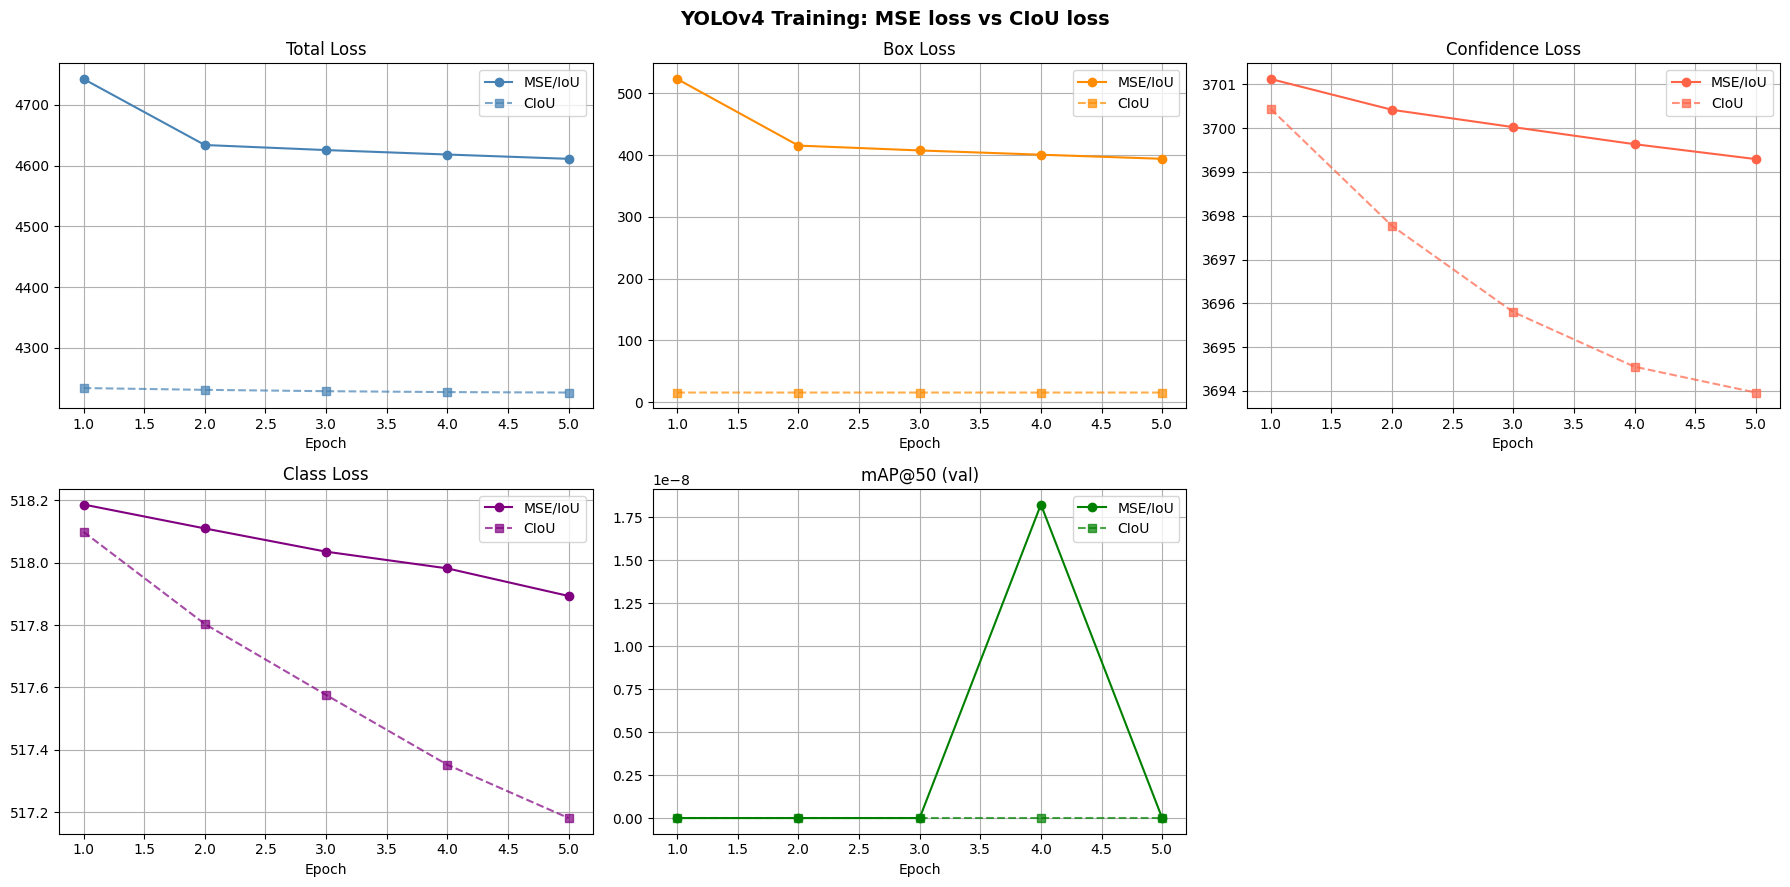


---- Loss Comparison -------------------------------------------
Loss type        Best mAP@50  Final Total Loss
-----------------------------------------------
MSE / IoU             0.0000         4611.1805
CIoU                  0.0000         4226.5901



In [40]:
# Plot training curves and print comparison table

import matplotlib.pyplot as plt
import numpy as np

epochs = list(range(1, 6))

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle("YOLOv4 Training: MSE loss vs CIoU loss", fontsize=14, fontweight="bold")

panels = [
    ("Total Loss",      "loss",  "steelblue"),
    ("Box Loss",        "box",   "darkorange"),
    ("Confidence Loss", "conf",  "tomato"),
    ("Class Loss",      "cls",   "purple"),
    ("mAP@50 (val)",    "map50", "green"),
]
for ax, (title, key, color) in zip(axes.flat, panels):
    ax.plot(epochs, history_mse[key],  marker='o', color=color, label='MSE/IoU', linestyle='-')
    ax.plot(epochs, history_ciou[key], marker='s', color=color, label='CIoU',    linestyle='--', alpha=0.7)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.grid(True); ax.legend()

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

best_mse  = max(history_mse["map50"])
best_ciou = max(history_ciou["map50"])
print("\n---- Loss Comparison -------------------------------------------")
print(f"{'Loss type':<15} {'Best mAP@50':>12}  {'Final Total Loss':>16}")
print("-" * 47)
print(f"{'MSE / IoU':<15} {best_mse:>12.4f}  {history_mse['loss'][-1]:>16.4f}")
print(f"{'CIoU':<15} {best_ciou:>12.4f}  {history_ciou['loss'][-1]:>16.4f}")
print()

---
## Exercise 3 - Why is YOLOv3 faster than Faster R-CNN?

**Answer:**

Faster R-CNN is a **two-stage detector**: it first runs a Region Proposal Network (RPN) that generates ~300 candidate boxes from the backbone feature map, then passes each proposal through a second detection head (via RoI Pooling) to classify and refine it. Even though the backbone is shared, the second stage requires a separate computation path *per proposal*, creating an unavoidable sequential bottleneck.

YOLOv3 is a **single-shot detector**: the image passes through the network exactly once and all bounding boxes plus class probabilities are predicted directly from three feature maps (at strides 8, 16, 32) in a single forward pass. There is no region-proposal stage, no RoI Pooling, and no per-region reprocessing. The entire detection - localisation and classification for all objects - is a single regression over a dense grid of anchor predictions.

| Aspect | Faster R-CNN | YOLOv3 |
|---|---|---|
| Number of forward passes | 2 (backbone + per-RoI head) | **1** |
| Proposal generation | RPN + NMS -> ~300 proposals | None (dense anchor grid) |
| Per-region processing | RoI Pooling + FC layers per proposal | No per-region operations |
| Output mechanism | Per-proposal classification + refinement | Direct regression from feature maps |
| Approximate speed | ~5 FPS | **30+ FPS** |

The absence of the second stage (no proposals, no RoI Pooling, no per-region network calls) is what enables YOLO's real-time throughput. The trade-off is that single-shot detectors historically struggled more with small, overlapping objects - a limitation that YOLOv3 addressed with multi-scale predictions at three grid resolutions.
